# Part 0
- Data cleaning.
- Data transformation.
- The above are achieved by converting most data types to numerical .
- Also cleaning data is very important because the models expect numerical data not strings.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import KNNImputer

URL = "https://raw.githubusercontent.com/krishna-koly/IMDB_TOP_1000/refs/heads/main/imdb_top_1000.csv"
df = pd.read_csv(URL)
print(df.shape)
print(df.dtypes)

(1000, 16)
Poster_Link       object
Series_Title      object
Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross             object
dtype: object


In [23]:
df_clean = df.copy()

df_clean['Runtime'] = pd.to_numeric(
    df_clean['Runtime'].str.replace(' min', '', regex=False), errors='coerce')
df_clean['Gross'] = pd.to_numeric(
    df_clean['Gross'].str.replace(',', '', regex=False), errors='coerce')
df_clean['Released_Year'] = pd.to_numeric(
    df_clean['Released_Year'], errors='coerce')

df_clean = df_clean.dropna(subset=['Released_Year'])
df_clean['Released_Year'] = df_clean['Released_Year'].astype(int)

missing = df_clean.isnull().sum()
print(missing[missing > 0])

Certificate    101
Meta_score     157
Gross          169
dtype: int64


*We make each of the datasets different since theyll have variations.*

In [24]:
df_clean_linear = df_clean.copy()
df_clean_full = df_clean.copy()

**Feature engineering**
- we map the certificates to just 4 values
- create Num_genres and one shot encode genres as well
- one shot encode the 4 certificates we created
- also add director appearences and no_of_prolific_actors and max_actor_count
- then we drop the columns we do not need 

In [25]:
def transform_certificate_genre_star_director(df_clean) :
    cert_map = {
        'G': 'Universal', 'U': 'Universal', 'PG': 'Universal',
        'GP': 'Universal', 'TV-PG': 'Universal', 'Passed': 'Universal',
        'Approved': 'Universal', 'UA': 'UnderSupervision',
        'U/A': 'UnderSupervision', 'PG-13': 'UnderSupervision',
        'TV-14': 'UnderSupervision', 'A': 'Adult', 'R': 'Adult',
        'TV-MA': 'Adult', 'Unrated': 'Adult', '16': 'Adult',
        'Unknown': 'Unknown'
    }
    df_clean['Certificate'] = df_clean['Certificate'].map(cert_map).fillna('Unknown')

    from sklearn.preprocessing import MultiLabelBinarizer

    df_clean['Genre_List'] = (df_clean['Genre']
        .str.split(',')
        .apply(lambda x: [g.strip() for g in x]))
    
    df_clean['Num_Genres'] = df_clean['Genre_List'].apply(len)

    mlb = MultiLabelBinarizer()
    genre_encoded = pd.DataFrame(
        mlb.fit_transform(df_clean['Genre_List']),
        columns=[f'Genre_{g}' for g in mlb.classes_],
        index=df_clean.index
    )

    cert_encoded = pd.get_dummies(df_clean['Certificate'], prefix='Cert')

    director_counts = df_clean['Director'].value_counts()
    df_clean['Director_appearences'] = df_clean['Director'].map(
        lambda x: director_counts[x] if x in director_counts else 0)

    all_actors = pd.concat([df_clean['Star1'], df_clean['Star2'],
                            df_clean['Star3'], df_clean['Star4']])
    actor_counts = all_actors.value_counts()

    def nr_of_prolific_actor(row):
        count = 0
        for col in ['Star1', 'Star2', 'Star3', 'Star4']:
            if actor_counts.get(row[col], 0) >= 3:
                count += 1
        return count
    
    def max_actor_count(row):
        return max(actor_counts.get(row[col], 0) for col in ['Star1', 'Star2', 'Star3', 'Star4'])

    df_clean['Max_Actor_Count'] = df_clean.apply(max_actor_count, axis=1)

    df_clean['Nr_of_Prolific_Actors'] = df_clean.apply(nr_of_prolific_actor, axis=1)

    df_clean = pd.concat([df_clean, genre_encoded, cert_encoded], axis=1)

    cols_to_drop = ['Poster_Link', 'Overview', 'Genre', 'Genre_List',
                    'Certificate', 'Director', 'Star1', 'Star2', 'Star3', 'Star4',
                    'Series_Title']
    df_clean = df_clean.drop(columns=cols_to_drop)

    print(f"Shape: {df_clean.shape}")
    print(f"Remaining NaNs: {df_clean.isnull().sum().sum()}")
    print(df_clean.dtypes)
    
    return df_clean
    
df_clean_linear = transform_certificate_genre_star_director(df_clean_linear)
df_clean_full = transform_certificate_genre_star_director(df_clean_full)

Shape: (999, 35)
Remaining NaNs: 326
Released_Year              int64
Runtime                    int64
IMDB_Rating              float64
Meta_score               float64
No_of_Votes                int64
Gross                    float64
Num_Genres                 int64
Director_appearences       int64
Max_Actor_Count            int64
Nr_of_Prolific_Actors      int64
Genre_Action               int64
Genre_Adventure            int64
Genre_Animation            int64
Genre_Biography            int64
Genre_Comedy               int64
Genre_Crime                int64
Genre_Drama                int64
Genre_Family               int64
Genre_Fantasy              int64
Genre_Film-Noir            int64
Genre_History              int64
Genre_Horror               int64
Genre_Music                int64
Genre_Musical              int64
Genre_Mystery              int64
Genre_Romance              int64
Genre_Sci-Fi               int64
Genre_Sport                int64
Genre_Thriller             int64
Genre_

**Convert bool to int**

In [26]:
def fix_from_bool_to_int (df_clean) :
    
    cert_cols = [col for col in df_clean.columns if col.startswith('Cert_')]
    df_clean[cert_cols] = df_clean[cert_cols].astype(int)

    print(df_clean[cert_cols].dtypes)
    return df_clean

df_clean_full = fix_from_bool_to_int(df_clean_full)
df_clean_linear = fix_from_bool_to_int(df_clean_linear)

Cert_Adult               int64
Cert_UnderSupervision    int64
Cert_Universal           int64
Cert_Unknown             int64
dtype: object
Cert_Adult               int64
Cert_UnderSupervision    int64
Cert_Universal           int64
Cert_Unknown             int64
dtype: object


**Managing missing values**
- instead of filling the NaNs with mean or median we decided to use knnimputer to compute in the n-dimension the distance from
- the other instances and take for the missing columns value the mean of the top k closest entities
- this has proven to yield better results than filling with mean/median.

In [27]:

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
def fix_from_bool_to_int (df_clean) :

    cols_to_impute = df_clean.columns.tolist()

    # scaler = StandardScaler()
    # scaled_data = scaler.fit_transform(df_clean[cols_to_impute])

    imputer = KNNImputer(n_neighbors=5)
    imputed_scaled = imputer.fit_transform(df_clean[cols_to_impute])

    # imputed_original = scaler.inverse_transform(imputed_scaled)
    df_clean[cols_to_impute] = imputed_scaled
    
    return df_clean

df_clean_full = fix_from_bool_to_int(df_clean_full)
df_clean_linear = fix_from_bool_to_int(df_clean_linear)

**Checking nr of outliers**
- here we check what columns need dealing with their outliers
- information later used for winsorizing

In [28]:
def check_outliers(df_clean):
    numerical_cols = ['Released_Year', 'Runtime', 'IMDB_Rating', 
                    'Meta_score', 'Gross', 'Max_Actor_Count',
                    'Nr_of_Prolific_Actors', 'Num_Genres', 'Director_appearences']

    for col in numerical_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        n = df_clean[(df_clean[col] < Q1 - 1.5*IQR) | 
                    (df_clean[col] > Q3 + 1.5*IQR)].shape[0]
        print(f"{col}: {n} outliers")
        
check_outliers(df_clean_linear)

Released_Year: 7 outliers
Runtime: 29 outliers
IMDB_Rating: 13 outliers
Meta_score: 22 outliers
Gross: 119 outliers
Max_Actor_Count: 40 outliers
Nr_of_Prolific_Actors: 0 outliers
Num_Genres: 0 outliers
Director_appearences: 85 outliers


**Handling outliers**
- insteaed of removing outliers from such a small dataset we decided
- it was better if we simply change their values to the lower or upper bounds
- this process is called winsorinzing

In [29]:
cols_to_winsorize = ['Released_Year', 'Runtime', 'IMDB_Rating', 'Meta_score', 
                     'Gross', 'Director_appearences', 'Max_Actor_Count']

for col in cols_to_winsorize:
    lower = df_clean_linear[col].quantile(0.05)
    upper = df_clean_linear[col].quantile(0.95)
    df_clean_linear[col] = df_clean_linear[col].clip(lower=lower, upper=upper)

# **Part1** What feature we choose based on a correlation matrix .

- The reasoning here is that we find the column that has the most correlation with all other 
columns therefore making it easiest to determine based on the other columns.
- We do this by creating a correlation matrix and summing the absolute values for each column.

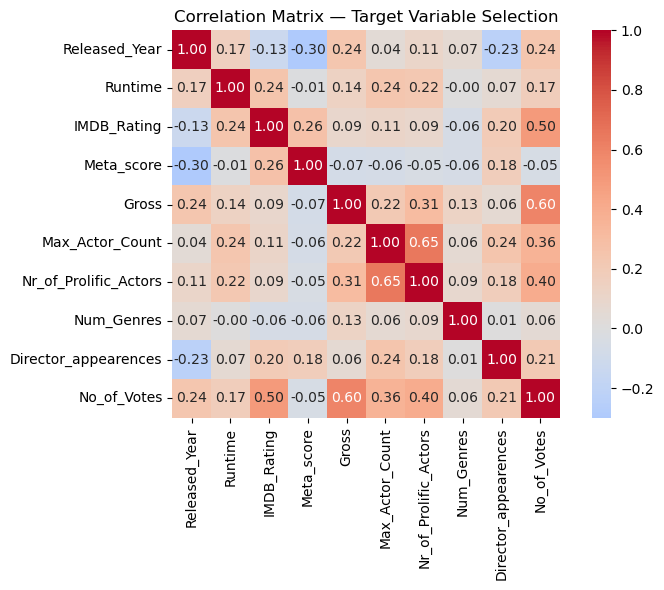

Total absolute correlation with other features:
No_of_Votes              2.582
Nr_of_Prolific_Actors    2.097
Max_Actor_Count          2.001
Gross                    1.854
IMDB_Rating              1.694
Released_Year            1.517
Director_appearences     1.377
Runtime                  1.267
Meta_score               1.044
Num_Genres               0.524
dtype: float64


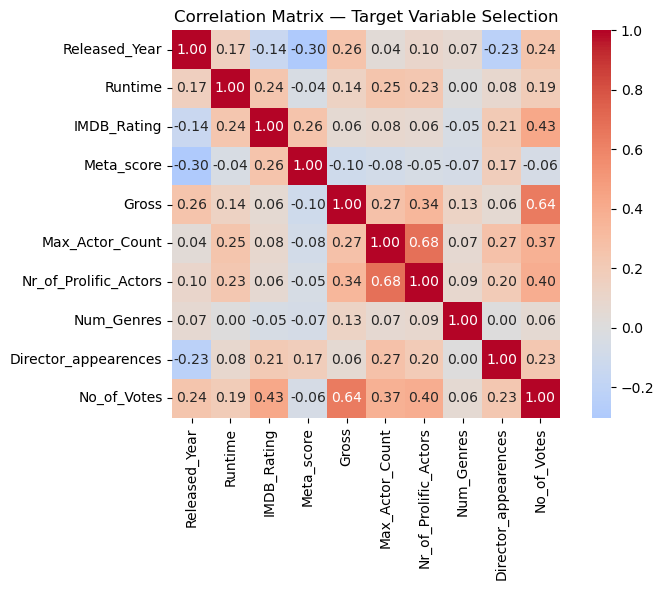

Total absolute correlation with other features:
No_of_Votes              2.616
Nr_of_Prolific_Actors    2.155
Max_Actor_Count          2.110
Gross                    1.994
Released_Year            1.541
IMDB_Rating              1.520
Director_appearences     1.457
Runtime                  1.342
Meta_score               1.131
Num_Genres               0.535
dtype: float64


In [30]:
def correlation_matrix(df_clean) :

    numerical_cols = ['Released_Year', 'Runtime', 'IMDB_Rating', 
                    'Meta_score', 'Gross', 'Max_Actor_Count',
                    'Nr_of_Prolific_Actors', 'Num_Genres', 'Director_appearences', 'No_of_Votes']

    corr_matrix = df_clean[numerical_cols].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, square=True)
    plt.title('Correlation Matrix — Target Variable Selection')
    plt.tight_layout()
    plt.show()

    corr_sums = corr_matrix.abs().sum() - 1  
    corr_sums = corr_sums.sort_values(ascending=False)
    print("Total absolute correlation with other features:")
    print(corr_sums.round(3))
    
correlation_matrix(df_clean_full)
correlation_matrix(df_clean_linear)

**Decision**
- based on the fact that for both the linear and full dataset we get
- the No_of_votes has the highest score makes the decision for the label
- an easy one .

 # Part2
 - Relevant features will be selected also based on the correlation matrix already done above.
 - The logarization of the label(target variable) is important since it removes the skewness.
 - As we observe most movies are clustered from(Vote counts POV) at the lower end (Logarization solves this by uniforming the distribution).
 - Based on abs feature correlation with new log label the columns get filtered for training and testing.

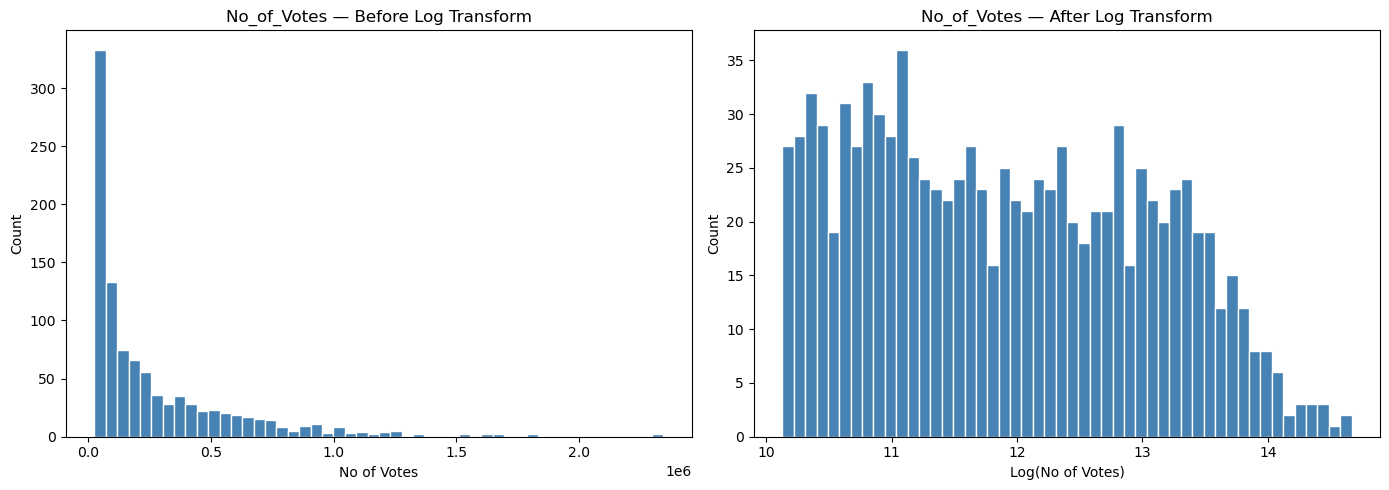

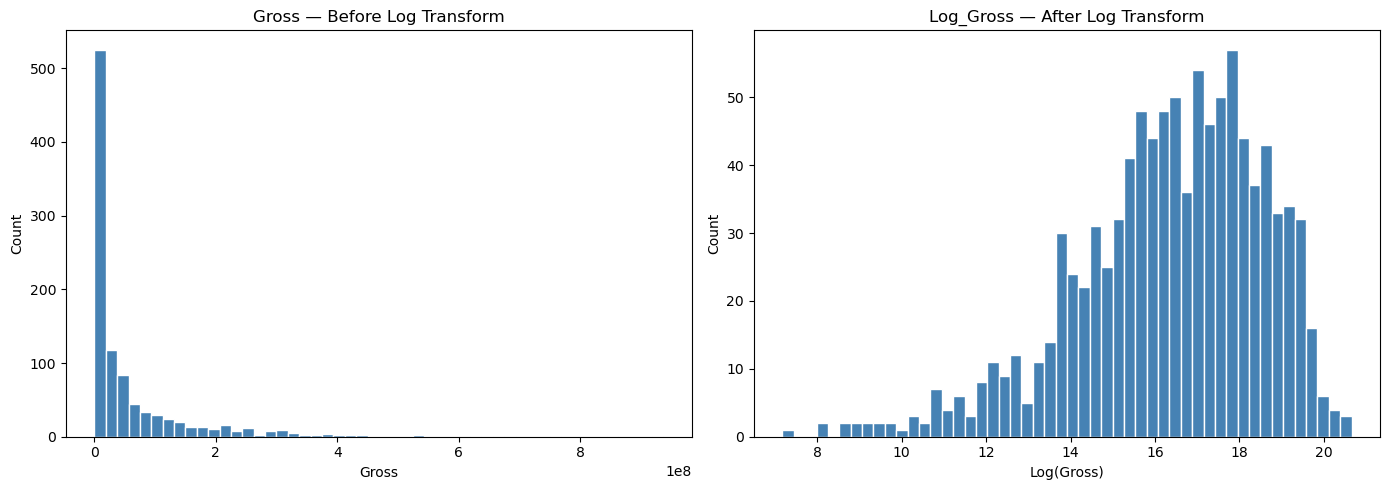

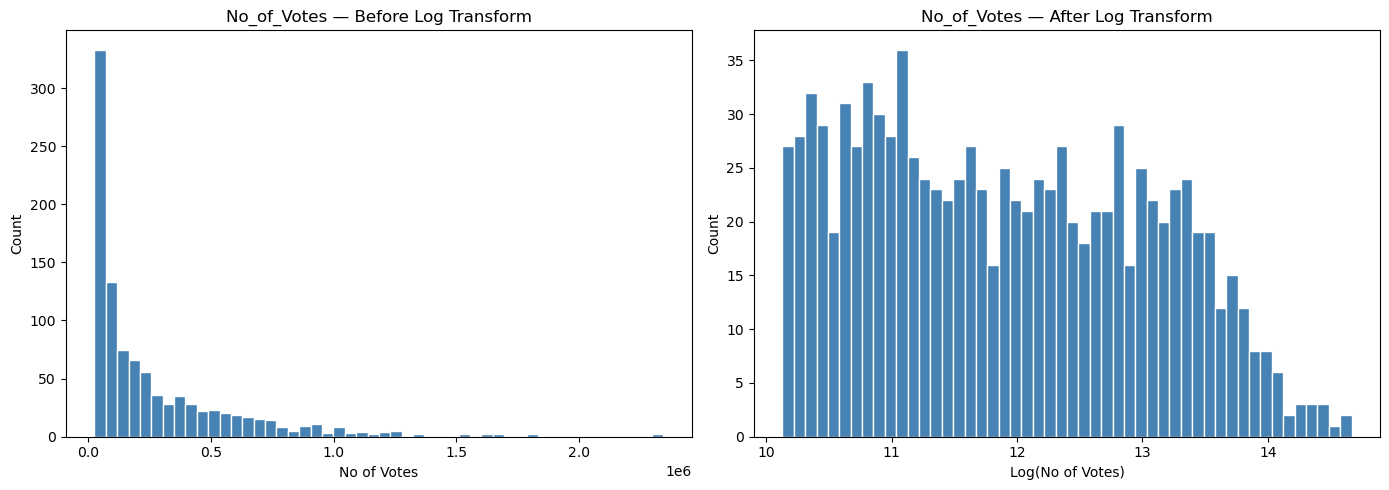

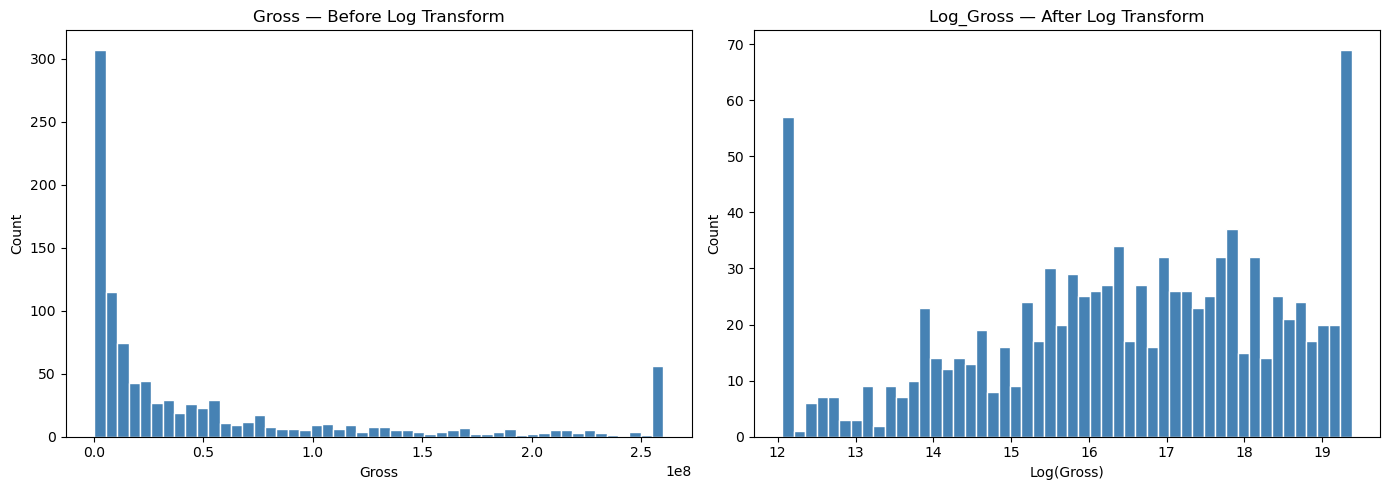

In [31]:
def logaritmize_votes_gross(df_clean):
    df_clean['Log_Votes'] = np.log1p(df_clean['No_of_Votes'])
    df_clean['Log_Gross'] = np.log1p(df_clean['Gross'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(df_clean['No_of_Votes'], bins=50,
                 color='steelblue', edgecolor='white')
    axes[0].set_title('No_of_Votes — Before Log Transform')
    axes[0].set_xlabel('No of Votes')
    axes[0].set_ylabel('Count')

    axes[1].hist(df_clean['Log_Votes'], bins=50,
                 color='steelblue', edgecolor='white')
    axes[1].set_title('No_of_Votes — After Log Transform')
    axes[1].set_xlabel('Log(No of Votes)')
    axes[1].set_ylabel('Count')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(df_clean['Gross'], bins=50,
                 color='steelblue', edgecolor='white')
    axes[0].set_title('Gross — Before Log Transform')
    axes[0].set_xlabel('Gross')
    axes[0].set_ylabel('Count')

    axes[1].hist(df_clean['Log_Gross'], bins=50,
                 color='steelblue', edgecolor='white')
    axes[1].set_title('Log_Gross — After Log Transform')
    axes[1].set_xlabel('Log(Gross)')
    axes[1].set_ylabel('Count')
    plt.tight_layout()
    plt.show()
    
logaritmize_votes_gross(df_clean_full)
logaritmize_votes_gross(df_clean_linear)

* Different view on the feature correlation part with the new logartimized label.

C:\Users\Mihai\AppData\Local\Temp\ipykernel_26620\3141434818.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='muted')


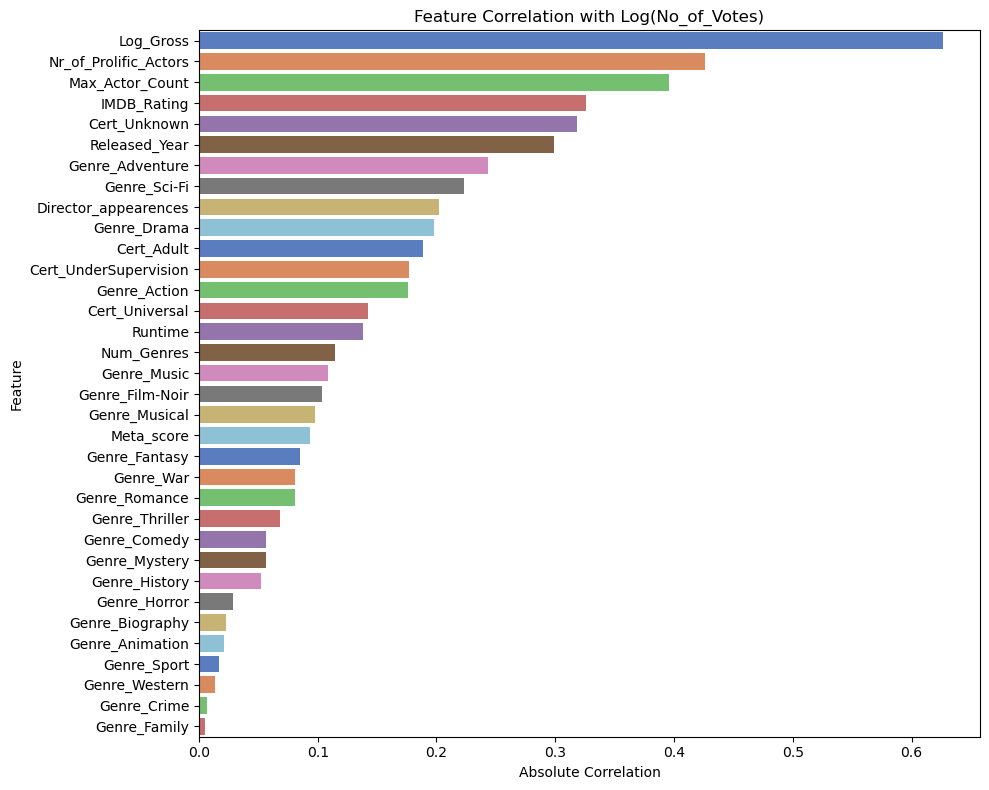

C:\Users\Mihai\AppData\Local\Temp\ipykernel_26620\3141434818.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='muted')


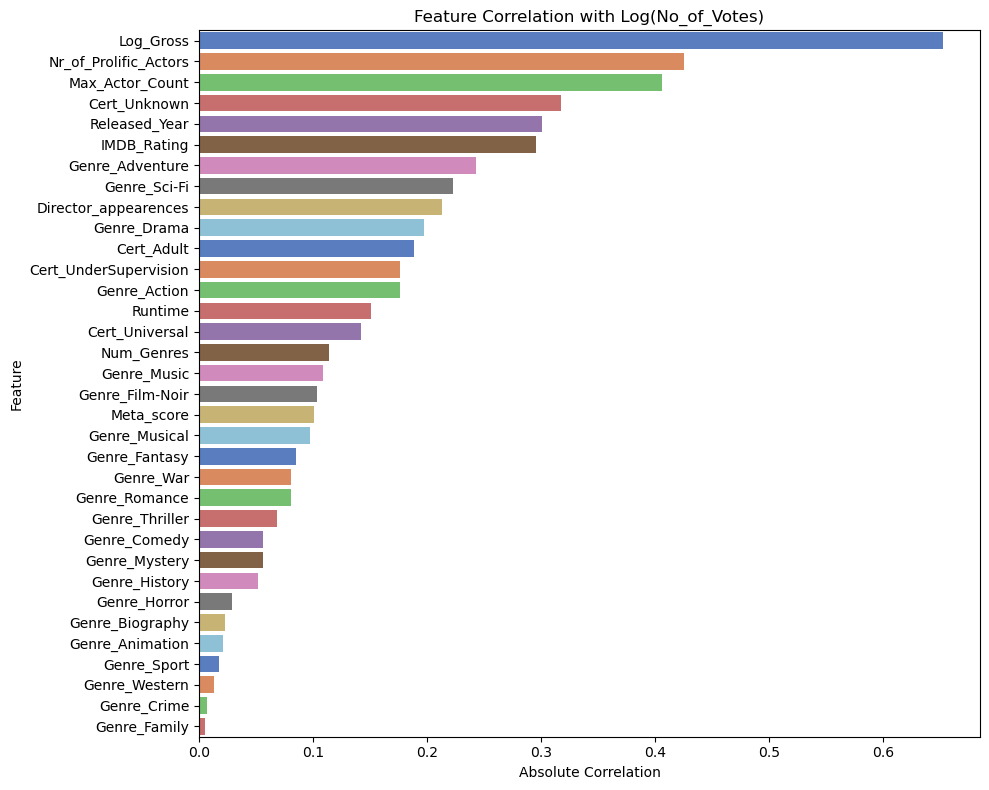

In [32]:
def feature_correlation(df_clean) :

    feature_cols = [col for col in df_clean.columns 
                    if col not in ['No_of_Votes', 'Log_Votes', 'Gross']]

    corr_with_target = df_clean[feature_cols].corrwith(df_clean['Log_Votes'])
    corr_with_target = corr_with_target.abs().sort_values(ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='muted')
    plt.title('Feature Correlation with Log(No_of_Votes)')
    plt.xlabel('Absolute Correlation')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    
    return corr_with_target
    
feature_correlation(df_clean_full)
corr_with_target = feature_correlation(df_clean_linear)

* Have chosen to keep all features that have at least an abs correlation above
* 0.10 as they are not plenty in number but also not few (We would have way less for 0.30 or 0.20)
* Here it can be tested with multiple values (0.05, 0.15, 0.20) and see best cross validated.

In [33]:
threshold = 0.10

selected_features = corr_with_target[corr_with_target >= threshold].index.tolist()

print(f"Selected features ({len(selected_features)}):")
for f in selected_features:
    print(f"  {f:<30} r={corr_with_target[f]:.3f}")

Selected features (19):
  Log_Gross                      r=0.653
  Nr_of_Prolific_Actors          r=0.426
  Max_Actor_Count                r=0.406
  Cert_Unknown                   r=0.318
  Released_Year                  r=0.301
  IMDB_Rating                    r=0.295
  Genre_Adventure                r=0.243
  Genre_Sci-Fi                   r=0.223
  Director_appearences           r=0.213
  Genre_Drama                    r=0.198
  Cert_Adult                     r=0.188
  Cert_UnderSupervision          r=0.177
  Genre_Action                   r=0.176
  Runtime                        r=0.151
  Cert_Universal                 r=0.142
  Num_Genres                     r=0.114
  Genre_Music                    r=0.109
  Genre_Film-Noir                r=0.104
  Meta_score                     r=0.101


In [34]:
X = df_clean_linear[selected_features]
y = df_clean_linear['Log_Votes']

X_linear = X.copy()
y_linear = y.copy()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

y_test
print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")

Training set:   (799, 19)
Test set:       (200, 19)


* Very important standartization is done such that features bear the sane importance no matter their unit and also
* it is easier from a computational point of view .
* This is done for LinearRegression based on the backbone of how the algorithm works
* Decision Tree and RandomForest do not need this.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape)

(799, 19)


# Part 3 - Training and Testing
- Here training and testing is done for our finetuned dataset on the 3 regression models
- For decision tree and random forest multiple hyperparameters are tried.

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"Linear Regression:")
print(f"RMSE:{rmse_lr}")
print(f"MAE:{mae_lr}")
print(f"R²:{r2_lr}")



Linear Regression:
RMSE:0.6514038899819062
MAE:0.5014184121549773
R²:0.630352459556592


In [37]:
tree_features = [col for col in df_clean_full.columns if col != 'Log_Votes' and col != 'No_of_Votes' and col != 'Gross']
X = df_clean_full[tree_features]
y = df_clean_full['Log_Votes']

X_tree = X.copy()
y_tree = y.copy()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")

Training set:   (799, 34)
Test set:       (200, 34)


In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': [3, 5, 7, 10, 15, 20, None],
              'min_samples_split': [2, 5, 10, 20, 50],
              'min_samples_leaf': [1, 2, 4, 8, 16]}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV R²: {grid_search.best_score_}")

dt_best = grid_search.best_estimator_
y_pred_dt = dt_best.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
r2_dt   = r2_score(y_test, y_pred_dt)

print(f"\nDecision Tree (tuned):")
print(f"RMSE:{rmse_dt}")
print(f"MAE:{mae_dt}")
print(f"R²:{r2_dt}")

Best parameters: {'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 2}
Best CV R²: 0.6213526254762807

Decision Tree (tuned):
RMSE:0.648702000015248
MAE:0.5116398422095407
R²:0.633412544695954


In [39]:
from sklearn.ensemble import RandomForestRegressor

param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search_rf.fit(X_train, y_train)

print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best CV R²: {grid_search_rf.best_score_:.4f}")

rf_best = grid_search_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest (tuned):")
print(f"RMSE:{rmse_rf}")
print(f"MAE:{mae_rf}")
print(f"R²:{r2_rf}")

Best parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R²: 0.7470

Random Forest (tuned):
RMSE:0.563673451672666
MAE:0.42328847665588837
R²:0.7232151681570622


            Model   RMSE    MAE     R²
Linear Regression 0.6514 0.5014 0.6304
    Decision Tree 0.6487 0.5116 0.6334
    Random Forest 0.5637 0.4233 0.7232


C:\Users\Mihai\AppData\Local\Temp\ipykernel_26620\3637718802.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results, palette='muted', ax=ax)
C:\Users\Mihai\AppData\Local\Temp\ipykernel_26620\3637718802.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results, palette='muted', ax=ax)
C:\Users\Mihai\AppData\Local\Temp\ipykernel_26620\3637718802.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results, palette='muted', ax=ax)


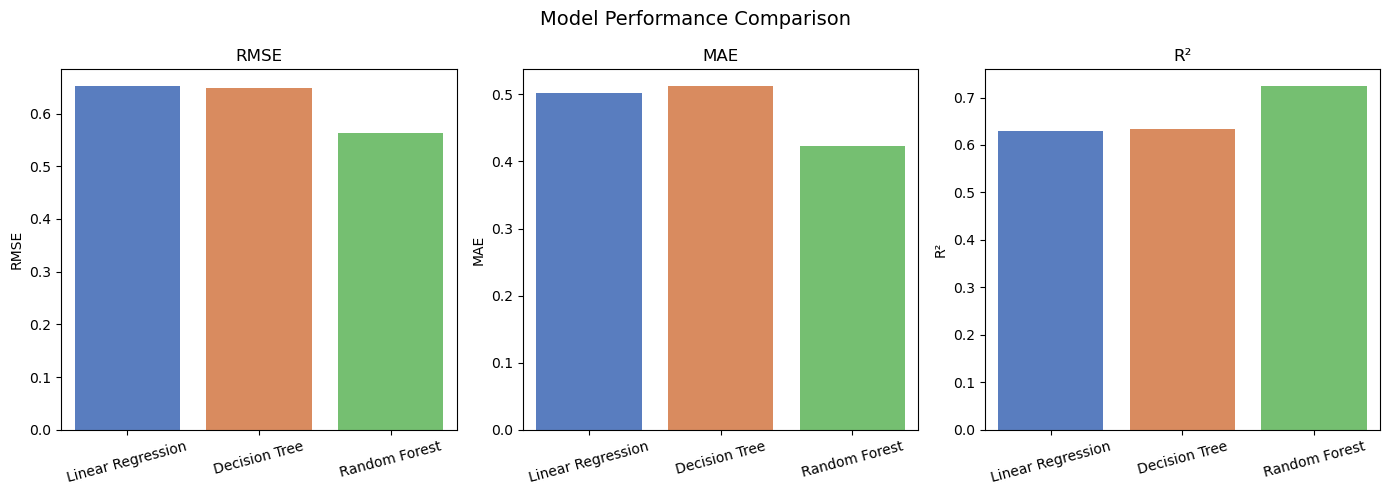

In [40]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'RMSE':  [rmse_lr, rmse_dt, rmse_rf],
    'MAE':   [mae_lr,  mae_dt,  mae_rf],
    'R²':    [r2_lr,   r2_dt,   r2_rf]
})

print(results.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    sns.barplot(x='Model', y=metric, data=results, palette='muted', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

 # **Part4** Model interpreatation and insights


***Models results analysys***
- random forest yields the best results
- tree based algorithms are better in this case , due to how they work.
- in comparison to linear regression which assumes a linear relationship between feature and label
- tree based models can also understand and take on and use non linear relationships
- and we can logically deduct that between the features we chose and out label there are not just linear relationships
- random forest performs even better than a simple decision tree as we can see from the results below because it makes decision
- based on multiple features compared to decision tree that heavely relies on log gross, because random forest simulates hundreds of trees.
- showing for random forests a more balanced feature importance

C:\Users\Mihai\AppData\Local\Temp\ipykernel_26620\1728102484.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dt_importance.values, y=dt_importance.index,
C:\Users\Mihai\AppData\Local\Temp\ipykernel_26620\1728102484.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance.values, y=rf_importance.index,


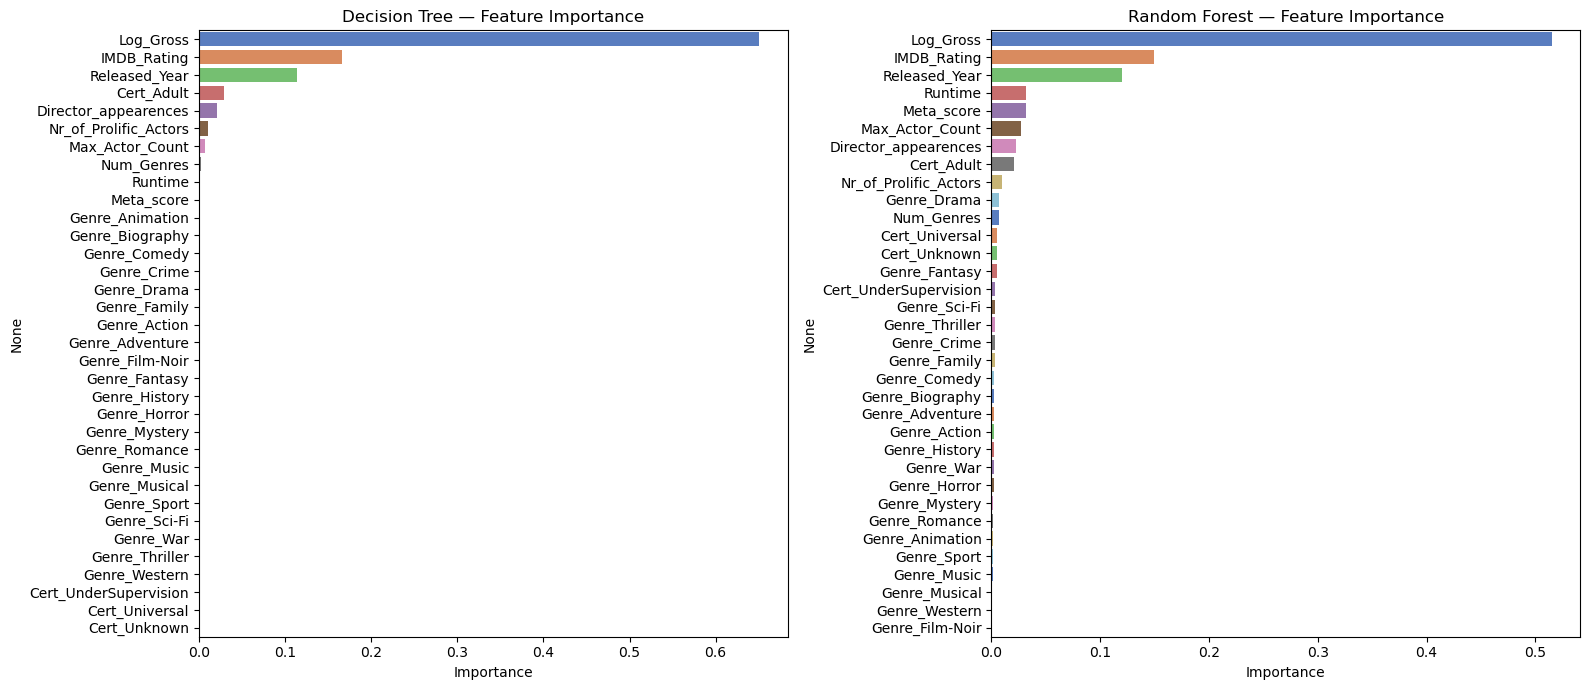

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

dt_importance = pd.Series(
    dt_best.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

sns.barplot(x=dt_importance.values, y=dt_importance.index, 
            palette='muted', ax=axes[0])
axes[0].set_title('Decision Tree — Feature Importance')
axes[0].set_xlabel('Importance')

rf_importance = pd.Series(
    rf_best.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

sns.barplot(x=rf_importance.values, y=rf_importance.index,
            palette='muted', ax=axes[1])
axes[1].set_title('Random Forest — Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

***Feature importance***
- as we can see that the most important for both models is gross(and this makes most sense
as both are results that are feedback for the movie (on the long run) so as votes grow usually gross grows as well
)
- imdb rating and released rating are close for 2nd and 3rd place showing that (on one side the nr of votes of a movie directly correlates with
its rating , and on the other side as movies are newer they get more votes since bigger population , more public mauybe even more people that get votes,
(what I mean is that maybe before u had to be a critic to vote, or people are more intrested about new movies rather than old ones when it comes to voting)
)
- we alsp see that for random forest the features we added -> max_actor_score and director appearences tend to yield some signal (in contrast to out genre
one hot encoded features), this may be due to the fact that people tend to vote more movies in which actual celebrities appear like(renowed actors or directors)

- also metascore, runtime and cert_adult appear these are pretty different :
    (1) metascore should be the same as imdv rating 
    (2) runtime here well longer movies or (120-150 min movies) are better to use in cinemas and on tv since they offer more screen time to tv companies
        therefore yielding more viewership -> more votes .. 
    (3) cert_adult speaks for itself since adults get to see these movies and them also beeing mostly I think at least that actually vote on these things
    




***Improvements***
- I feel that the certificate, and genre columns are not used to their maximum, this 
has to be explored further but I am sure that there is a way of combining them with other 
columns to offer more signal rather then noise.
- This maybe can be done the same for overview feature to extract emotion, or opinnion about the movie
- also maybe by using a webscraper we can obtain other important detaild about our data such as (important political movements(who is at power what values they support , often movies presenting oposing views yield great results), or civical movements(this speaks for itself), or economical movements(how many people have time and want to watch movies,  what i am saying people tend to  watch movies and go to the cinema more when the world is going well), maybe sport and art related information might help(for documentaries, and biografies) simply data on the actoes and directos, people love drama).
- even though I am no expert I think that the attempt of using different models might yield better results ->trying Gradient Boosting (XGBoos) which builds trees sequentially, where each new tree corrects the errors of the previous ones this often outperforms Random Forest(source the internet).



# Bonus

In [42]:
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

cv_lr = cross_val_score(lr_pipe, X_linear, y_linear, cv=10, scoring='r2')
print(f"Linear Regression  10-Fold CV R²: {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}")


cv_dt = cross_val_score(dt_best, X_tree, y_tree, cv=10, scoring='r2')
print(f"Decision Tree 10-Fold CV R²: {cv_dt.mean():.4f} +/- {cv_dt.std():.4f}")

cv_rf = cross_val_score(rf_best, X_tree, y_tree, cv=10, scoring='r2')
print(f"Random Forest 10-Fold CV R²: {cv_rf.mean():.4f} +/- {cv_rf.std():.4f}")

Linear Regression  10-Fold CV R²: 0.5713 +/- 0.0795
Decision Tree 10-Fold CV R²: 0.4742 +/- 0.1536
Random Forest 10-Fold CV R²: 0.6386 +/- 0.1069


*Understanding cross-validation*
- linear regression does not overfit(or it does the least)(consistency)
- decision tree is greedy and gets different results(depending on what it trains)(it overfits)
- random forest best result across but is a little bit less consistent than linear regression when it comes
to the dataset it trains on